# Rolling Shutter Image as an IMU

This notebook implements a rolling shutter camera motion estimation pipeline that combines:
- **RS-Diffusion Model**: Predicts optical flow from rolling shutter images
- **Depth Estimation**: Uses SegNext-based depth prediction
- **Motion Solver**: Computes per-scanline camera poses from flow and depth
- **IMU Comparison**: Validates estimated velocities against ground-truth IMU readings

## Overview
The pipeline processes rolling shutter images to estimate angular and translational velocities by:
1. Predicting dense optical flow using a diffusion model
2. Estimating depth from the input image
3. Solving for camera motion per row or row group using the rolling shutter model
4. Aggregating row-wise poses into frame-level velocity estimates
5. Comparing results with baseline methods (IAAI) and IMU ground truth

## 1. Import Dependencies

Read the README for installing dependencies

In [1]:
import csv
import yaml
import torch
import numpy as np
from pathlib import Path
from PIL import Image
import cv2
from torchvision import transforms as T
from torchvision import utils
from tqdm import tqdm
import matplotlib.pyplot as plt
import roma
from  torchvision.transforms.functional import normalize
# Import model components
from rsaai.model.diffusion_model import Unet, RS_Diffusion
from rsaai.util.flow_utils import flow_to_image, flow_warp, upsample2d_flow_320_224, upsample2d_flow_as, flow_to_image_luo

from rsaai.model.blur_2_pose_model import Blur2PoseSegNeXtBackbone
from rsaai.model.funcs import compute_single_image_velocity


/home/prashanth/miniconda3/envs/rolling-shutter-as-an-imu/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/prashanth/miniconda3/envs/rolling-shutter-as-an-imu/lib/python3.11/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/prashanth/projects/rolling-shutter-as-an-imu/rsaai/model/diffusion_model.py:831: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled = False)


## 3. Initialize Models

Load the trained RS-Diffusion model and configure device settings. The model predicts dense optical flow from rolling shutter images, which is essential for subsequent motion estimation.

In [2]:
def load_model(config_path, checkpoint_path, device):
    """
    Load the trained Ours model with EMA weights.
    
    Args:
        config_path (str): Path to configuration YAML file
        checkpoint_path (str): Path to model checkpoint
        device (str): Device to load model on ('cuda' or 'cpu')
    
    Returns:
        tuple: (model, config) - Loaded diffusion model with EMA and configuration dict
    """
    # Load configuration
    with open(config_path, "r") as f:
        config = yaml.safe_load(f)
    
    print(f"Loading configuration from: {config_path}")
    print(f"Loading checkpoint from: {checkpoint_path}")
    
    # Initialize the U-Net model
    model = Unet(
        dim=config["model"]["dim"],
        dim_mults=tuple(config["model"]["dim_mults"]),
        num_classes=config["model"]["num_classes"],
        cond_drop_prob=config["model"]["cond_drop_prob"],
    )
    
    # Initialize the diffusion model
    diffusion = RS_Diffusion(
        model,
        image_size=config["diffusion"]["image_size"],
        timesteps=config["diffusion"]["timesteps"],
        sampling_timesteps=config["diffusion"]["sampling_timesteps"],
        beta_schedule=config["diffusion"]["beta_schedule"],
        objective=config["diffusion"]["objective"],
    ).to(device)
    
    # Load checkpoint
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    # Load the EMA model state
    if 'ema' in checkpoint:
        from ema_pytorch import EMA
        ema = EMA(diffusion, beta=0.995, update_every=10)
        ema.load_state_dict(checkpoint['ema'])
        ema.ema_model.eval()
        print(f"Model loaded successfully with EMA on {device}")
        return ema.ema_model, config
    elif 'model' in checkpoint:
        diffusion.load_state_dict(checkpoint['model'])
        diffusion.eval()
        print(f"Model loaded successfully on {device}")
        return diffusion, config
    else:
        diffusion.load_state_dict(checkpoint)
        diffusion.eval()
        print(f"Model loaded successfully on {device}")
        return diffusion, config


def preprocess_image(image_path, image_size, original_size=None):
    """
    Preprocess a single image for model itorchut.
    
    Args:
        image_path (str or Path): Path to the itorchut image
        image_size (int): Target size for the image (will be resized to image_size x image_size)
        original_size (tuple): Optional original size to resize to for output, if None uses image's natural size
    
    Returns:
        tuple: (preprocessed_tensor, original_tensor, original_image) 
               - preprocessed_tensor: Tensor ready for model input (1, 3, H, W) at image_size
               - original_tensor: Tensor at original resolution for warping (1, 3, H_orig, W_orig)
               - original_image: PIL Image object of the original image
    """
    # Load image
    img = Image.open(image_path).convert('RGB')
    img_size = img.size
    
    if original_size is None:
        original_size = img_size
    
    # Transform for model input (downsampled)
    transform_model = T.Compose([
        T.Resize((image_size, image_size)),
        T.ToTensor()
    ])
    
    # Transform for output display (original or specified resolution)
    transform_output = T.Compose([
        T.Resize(original_size) if original_size != img_size else T.Lambda(lambda x: x),
        T.ToTensor()
    ])
    
    # Process image
    img_tensor_model = transform_model(img).unsqueeze(0)  # For model: (1, 3, image_size, image_size)
    img_tensor_output = transform_output(img).unsqueeze(0)  # For warping: (1, 3, H, W)
    
    print(f"Loaded image: {image_path}")
    print(f"Original size: {img_size}, Model input size: {image_size}x{image_size}, Output size: {original_size}")
    
    return img_tensor_model, img_tensor_output, img

def run_inference(diffusion, img_tensor, device, cond_scale=1.0, rescaled_phi=0.7):
    """
    Run inference on a preprocessed image tensor to predict optical flow.
    
    Args:
        diffusion: RS_Diffusion model
        img_tensor: Preprocessed image tensor (1, 3, H, W)
        device: Device to run inference on
        cond_scale: Classifier-free guidance scale
        rescaled_phi: Rescaled phi parameter for guidance
    
    Returns:
        torch.Tensor: Predicted optical flow (1, 2, H, W)
    """
    img_tensor = img_tensor.to(device)
    
    with torch.no_grad():
        # Run diffusion sampling to predict flow
        # For single image inference, we use class 0
        classes = torch.zeros(1, dtype=torch.long).to(device)
        
        # Use the sample method with guidance to get flow prediction
        predicted_flow = diffusion.sample(
            classes=classes,
            condition=img_tensor,
            cond_scale=cond_scale,
            rescaled_phi=rescaled_phi
        )
        
    return predicted_flow
def run_inference(diffusion, img_tensor, device, cond_scale=1.0, rescaled_phi=0.7):
    """
    Run inference on a preprocessed image tensor to predict optical flow.
    
    Args:
        diffusion: RS_Diffusion model
        img_tensor: Preprocessed image tensor (1, 3, H, W)
        device: Device to run inference on
        cond_scale: Classifier-free guidance scale
        rescaled_phi: Rescaled phi parameter for guidance
    
    Returns:
        torch.Tensor: Predicted optical flow (1, 2, H, W)
    """
    img_tensor = img_tensor.to(device)
    
    with torch.no_grad():
        # Run diffusion sampling to predict flow
        # For single image inference, we use class 0
        classes = torch.zeros(1, dtype=torch.long).to(device)
        
        # Use the sample method with guidance to get flow prediction
        predicted_flow = diffusion.sample(
            classes=classes,
            condition=img_tensor,
            cond_scale=cond_scale,
            rescaled_phi=rescaled_phi
        )
        
    return predicted_flow


def save_results(output_dir, image_name, corrected_img_tensor, flow_np, original_img_tensor, save_flow_viz=True):
    """
    Save inference results to disk.
    
    Args:
        output_dir (Path): Output directory
        image_name (str): Name of the input image (without extension)
        corrected_img_tensor: Corrected image tensor (1, 3, H, W)
        flow_np: Optical flow array (H, W, 2)
        original_img_tensor: Original RS image tensor (1, 3, H, W)
        save_flow_viz: Whether to save flow visualization
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # Save corrected image
    corrected_path = output_dir / f"{image_name}_corrected.png"
    utils.save_image(corrected_img_tensor, str(corrected_path))
    print(f"Saved corrected image: {corrected_path}")
    
    # Save flow as numpy array
    flow_path = output_dir / f"{image_name}_flow.npy"
    np.save(flow_path, flow_np)
    print(f"Saved flow array: {flow_path}")
    
    # Save flow visualization
    if save_flow_viz:
        flow_viz = flow_to_image(flow_np)
        flow_viz_path = output_dir / f"{image_name}_flow_viz.png"
        cv2.imwrite(str(flow_viz_path), flow_viz)
        print(f"Saved flow visualization: {flow_viz_path}")
    
    # Create comparison image (RS | Corrected)
    comparison = torch.cat([original_img_tensor, corrected_img_tensor], dim=3)  # Concatenate along width
    comparison_path = output_dir / f"{image_name}_comparison.png"
    utils.save_image(comparison, str(comparison_path))
    print(f"Saved comparison image: {comparison_path}")

In [3]:

device = "cuda" if torch.cuda.is_available() else "cpu"

checkpoint_path = Path("checkpoint/RS_Real.pt")
config_path = Path("config/RS_real_config_teat.yaml")

diffusion, config = load_model(config_path, checkpoint_path, device)

image_size = config["diffusion"]["image_size"]

blur_2_pose_model = Blur2PoseSegNeXtBackbone(device=device)
state_dict = torch.load("checkpoint/segnext_iaai.pth")
blur_2_pose_model.load_state_dict(state_dict, strict=True)
blur_2_pose_model.eval().cuda()

Loading configuration from: config/RS_real_config_teat.yaml
Loading checkpoint from: checkpoint/RS_Real.pt
Model loaded successfully with EMA on cuda


Blur2PoseSegNeXtBackbone(
  (backbone): MSCAN(
    (patch_embed1): StemConv(
      (proj): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): GELU(approximate='none')
        (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (block1): ModuleList(
      (0-2): 3 x Block(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (attn): SpatialAttention(
          (proj_1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
          (activation): GELU(approximate='none')
          (spatial_gating_unit): AttentionModule(
            (conv0): Conv2d(64, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), groups=64)
            (conv0_1): Conv2d(64, 64, kernel_size=(1, 

## 4. Single Image Demo: Flow and Depth Visualization

This section demonstrates the pipeline on a single test image:
1. Load and preprocess the input rolling shutter image
2. Run RS-Diffusion inference to predict optical flow
3. Upsample flow to the target resolution
4. Predict depth using the SegNext-based depth model
5. Visualize both flow magnitude and depth maps side-by-side

Loaded image: /home/prashanth/projects/rolling-shutter-as-an-imu/datasets/new_college_scene/rgb/rgb_1813639892000_1646.png
Original size: (1280, 720), Model input size: 64x64, Output size: (1280, 720)


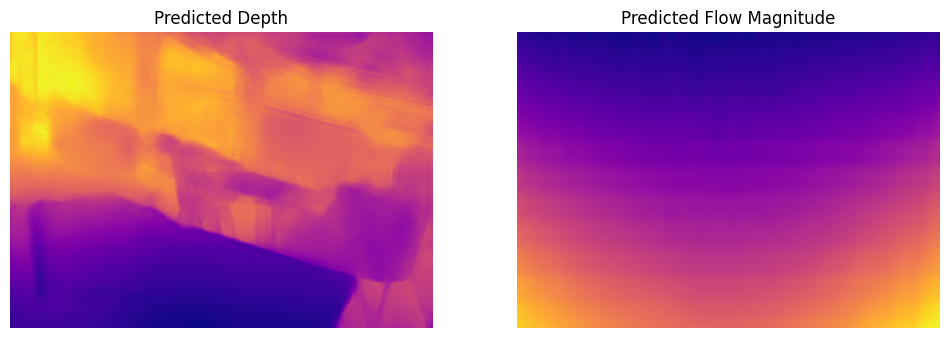

In [47]:
image_path = Path("/home/prashanth/projects/rolling-shutter-as-an-imu/datasets/new_college_scene/rgb/rgb_1813639892000_1646.png")
original_img = Image.open(image_path).convert('RGB')

img_tensor_model, img_tensor_output, _ = preprocess_image(
        image_path, 
        image_size,
        original_size=original_img.size
)
img_tensor_output = img_tensor_output.to(device)

predicted_flow = run_inference(
    diffusion, 
    img_tensor_model, 
    device,
)

flow_upsampled = upsample2d_flow_320_224(
    predicted_flow, if_rate=True
)

flow_np = flow_upsampled.squeeze().cpu().numpy().transpose(1, 2, 0)


data = {"image": original_img, "fx": 1550.3420, "fy": 1550.3420}
blur_2_pose_out = blur_2_pose_model.infer(data)
blur_2_pose_model.supervise_pose = True
depth = blur_2_pose_out["depth"]
depth_np = depth.squeeze().cpu().numpy()
# visualize depth and flow seperately
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Predicted Depth")
plt.imshow(depth_np, cmap='plasma')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.title("Predicted Flow Magnitude")
flow_magnitude = np.sqrt(flow_np[..., 0]**2 + flow_np[..., 1]**2)
plt.imshow(flow_magnitude, cmap='plasma')
plt.axis('off')
plt.show()

# normalize and colourize the depth map for saving
normalized_depth = (depth_np - np.min(depth_np)) / (np.max(depth_np) - np.min(depth_np))
depth_colored = plt.get_cmap('plasma')(normalized_depth)[:, :, :3]  # Get RGB channels
depth_colored = (depth_colored * 255).astype(np.uint8)

## 5. Core Motion Estimation Algorithm

This section implements the main rolling shutter motion solver:

### `compute_rolling_to_global_motion`
Estimates camera pose per row group by solving the rolling shutter model:
- **Input**: Optical flow, depth map, focal length
- **Process**: Formulates a linear system Ax = b for each row group where:
  - A encodes the rolling shutter projection equations
  - x = [ωx, ωy, ωz, tx, ty, tz] is the 6-DOF motion vector
  - b is the observed optical flow
- **Output**: 6-DOF pose (rotation + translation) per row group

### `compute_average_motion`
Aggregates per-row poses into a single velocity estimate:
- Converts Euler angles to rotation matrices
- Computes frame-to-frame relative motions
- Smooths motion deltas using 1D averaging
- Supports multiple aggregation methods (mean, median, trimmed mean, linear regression)
- Returns angular and translational velocities scaled by exposure time

In [48]:
def compute_rolling_to_global_motion(
    flow_B2HW,
    depths_BHW,
    fl_B,
    *,
    cut_border_amnt: int = 20,
    sample_n: int = 1,
    row_group_size: int = 8,
    use_pinv: bool = True,
):
    """Estimate camera motion per row group using dense flow and depth.

    Args:
        flow_B2HW: Optical flow tensor shaped (B, 2, H, W).
        depths_BHW: Depth tensor shaped (B, H, W) or (B, 1, H, W).
        fl_B: Batch of focal lengths (B,).
        cut_border_amnt: Symmetric border width (pixels) to ignore.
        sample_n: Column subsampling stride to reduce solve size.
        row_group_size: Number of consecutive rows to bundle into a single solve.
        use_pinv: Whether to use Moore--Penrose pseudo-inverse (else lstsq).

    Returns:
        Tuple[torch.Tensor, torch.Tensor]:
            - solution tensor shaped (B, G, 6) where G is the number of row groups.
            - residual norm per group shaped (B, G).
    """
    device = flow_B2HW.device
    dtype = flow_B2HW.dtype
    B, _, H, W = flow_B2HW.shape
    sample_stride = max(int(sample_n), 1)
    solve_with_pinv = use_pinv
    if cut_border_amnt > 0:
        flow_roi = flow_B2HW[..., cut_border_amnt:-cut_border_amnt, cut_border_amnt:-cut_border_amnt]
        depths_roi = depths_BHW[..., cut_border_amnt:-cut_border_amnt, cut_border_amnt:-cut_border_amnt]
        i_centers = torch.arange(cut_border_amnt, H - cut_border_amnt, device=device)
        j_centers = torch.arange(cut_border_amnt, W - cut_border_amnt, device=device)
    else:
        flow_roi = flow_B2HW
        depths_roi = depths_BHW
        i_centers = torch.arange(H, device=device)
        j_centers = torch.arange(W, device=device)
    _, _, H_eff, W_eff = flow_roi.shape
    if depths_roi.dim() == 4 and depths_roi.size(1) == 1:
        depths_roi = depths_roi.squeeze(1)
    depths_roi = depths_roi.to(device)
    depths_safe = depths_roi.clamp_min(1e-6)
    X, Y = torch.meshgrid(j_centers, i_centers, indexing="xy")
    X = X.to(device)
    Y = Y.to(device)
    u = (X - W / 2.0).unsqueeze(0).expand(B, -1, -1)
    v = (Y - H / 2.0).unsqueeze(0).expand(B, -1, -1)
    fl = fl_B.view(B, 1, 1).expand(B, H_eff, W_eff).to(device)
    zeros = torch.zeros_like(u)
    Ax1 = (u * v) / fl  # omega_x
    Ay1 = -(fl + (u ** 2) / fl)  # omega_y
    Az1 = v  # omega_z
    Tx1 = -fl / depths_safe  # translation_x
    Ty1 = zeros  # translation_y
    Tz1 = u / depths_safe
    Ax2 = (fl + (v ** 2) / fl)  # omega_x
    Ay2 = -(u * v) / fl  # omega_y
    Az2 = -u  # omega_z
    Tx2 = zeros  # translation_x
    Ty2 = -fl / depths_safe  # translation_y
    Tz2 = v / depths_safe  # translation_z
    A_terms = torch.stack([Ax1, Ay1, Az1, Tx1, Ty1, Tz1, Ax2, Ay2, Az2, Tx2, Ty2, Tz2], dim=-1)
    flow_rows = flow_roi.permute(0, 2, 3, 1)
    A_terms = A_terms[:, :, ::sample_stride, :]
    flow_rows = flow_rows[:, :, ::sample_stride, :]
    B_dim, H_dim, W_samp, _ = A_terms.shape
    # Each pixel contributes two flow equations; reshape accordingly before grouping rows.
    A_terms = A_terms.view(B_dim, H_dim, W_samp, 2, 6).reshape(B_dim, H_dim, W_samp * 2, 6)
    flow_rows = flow_rows.view(B_dim, H_dim, W_samp, 2, 1).reshape(B_dim, H_dim, W_samp * 2, 1)
    samples_per_row = W_samp * 2
    row_group_size = max(int(row_group_size), 1)
    if row_group_size > H_dim:
        raise ValueError("row_group_size must be <= number of effective rows")
    valid_rows = (H_dim // row_group_size) * row_group_size
    if valid_rows == 0:
        raise ValueError("row_group_size too large for available rows after cropping")
    if valid_rows < H_dim:
        # Drop leftover rows that don't fill a complete group to keep tensor shapes uniform.
        A_terms = A_terms[:, :valid_rows]
        flow_rows = flow_rows[:, :valid_rows]
    group_count = valid_rows // row_group_size
    A_terms = A_terms.view(B_dim, group_count, row_group_size, samples_per_row, 6)
    flow_rows = flow_rows.view(B_dim, group_count, row_group_size, samples_per_row, 1)
    # Collapse all samples within each group into a single linear system per group.
    A_terms = A_terms.reshape(B_dim, group_count, row_group_size * samples_per_row, 6)
    flow_rows = flow_rows.reshape(B_dim, group_count, row_group_size * samples_per_row, 1)
    A_solver = A_terms.reshape(B_dim * group_count, row_group_size * samples_per_row, 6).float()
    b_solver = flow_rows.reshape(B_dim * group_count, row_group_size * samples_per_row, 1).float()
    if solve_with_pinv:
        x_solution = torch.linalg.pinv(A_solver) @ b_solver
        residual = torch.norm(A_solver @ x_solution - b_solver, dim=1)
    else:
        x_solution, residual, _, _ = torch.linalg.lstsq(A_solver, b_solver, driver="gels")
    x_solution = x_solution.reshape(B_dim, group_count, 6).to(dtype)
    residual = residual.reshape(B_dim, group_count).to(dtype)
    return x_solution, residual

In [49]:
def compute_average_motion(solution, method: str = "mean", trim_ratio: float = 0.1, dt = 1.0):
    """Aggregate per-row motion into a single velocity/rotation estimate."""
    poses = solution.squeeze(0)
    euler_angles = poses[..., :3]
    translations = poses[..., 3:]
    R_i_to_1 = roma.euler_to_rotmat('XYZ', euler_angles)
    R_1_to_i = R_i_to_1.transpose(-2, -1)
    t_1_to_i = -torch.bmm(R_1_to_i, translations.unsqueeze(-1)).squeeze(-1)
    pos_deltas = t_1_to_i[1:] - t_1_to_i[:-1]
    R_rel = R_1_to_i[1:] @ R_1_to_i[:-1].transpose(-2, -1)
    omega_deltas = roma.rotmat_to_euler('XYZ', R_rel)
    method = method.lower()
    if method not in {"mean", "median", "trimmed", "linear"}:
        raise ValueError("method must be one of {'mean','median','trimmed','linear'}")
    def aggregate(sequence: torch.Tensor) -> torch.Tensor:
        if method == "mean":
            return sequence.mean(dim=0)
        if method == "median":
            return sequence.median(dim=0).values
        if method == "trimmed":
            n = sequence.shape[0]
            k = int(trim_ratio * n)
            if k == 0 or (n - 2 * k) <= 0:
                return sequence.mean(dim=0)
            sorted_vals, _ = torch.sort(sequence, dim=0)
            trimmed_vals = sorted_vals[k:n - k]
            return trimmed_vals.mean(dim=0)
        if method == "linear":
            indices = torch.arange(sequence.shape[0], dtype=sequence.dtype, device=sequence.device).unsqueeze(1)
            ones = torch.ones_like(indices)
            design = torch.cat([indices, ones], dim=1)
            coeffs = torch.linalg.pinv(design) @ sequence
            slope = coeffs[0]
            return slope
        raise RuntimeError("Unhandled aggregation method")
    # smooth deltas before aggregating
    pos_deltas = torch.nn.functional.avg_pool1d(
        pos_deltas.unsqueeze(0).permute(0, 2, 1), 
        kernel_size=5, 
        stride=1, 
        padding=2
    ).permute(0, 2, 1).squeeze(0)
    omega_deltas = torch.nn.functional.avg_pool1d(
        omega_deltas.unsqueeze(0).permute(0, 2, 1), 
        kernel_size=5, 
        stride=1, 
        padding=2
    ).permute(0, 2, 1).squeeze(0)
    
    v_avg = aggregate(pos_deltas) / dt
    omega_avg = aggregate(omega_deltas) / dt
    return v_avg, omega_avg

## 6. 3D Trajectory Visualization

Visualize the estimated camera trajectory in 3D space for different row grouping strategies. This helps assess:
- **Spatial consistency** of the estimated poses
- **Effect of row grouping** on trajectory smoothness
- **Camera orientation** changes across scanlines

Each subplot shows:
- Camera path (line)
- Start position (green) and end position (red)
- Camera orientation axes (RGB quivers) at regular intervals

In [50]:
focal_length = 1550.3420
#adjust focal length to scale
# Adjust focal length for cropping and resizing
# original image size is 4056x3040
scale_x = 320 / 4056
scale_y = 224 / 3040
fx = focal_length * scale_x
fy = focal_length * scale_y
scaled_focal_length = (fx + fy) / 2

# Compute motion with different row grouping strategies
# Smaller groups = higher temporal resolution but noisier estimates
# Larger groups = smoother but lower temporal resolution
solution_1, residual = compute_rolling_to_global_motion(flow_upsampled, depth, torch.tensor([scaled_focal_length], device=device), row_group_size=1)
solution_4, residual = compute_rolling_to_global_motion(flow_upsampled, depth, torch.tensor([scaled_focal_length], device=device), row_group_size=4)
solution_10, residual = compute_rolling_to_global_motion(flow_upsampled, depth, torch.tensor([scaled_focal_length], device=device), row_group_size=10)

In [92]:
%matplotlib qt
def _rotation_matrix_from_vector(rot_vec: torch.Tensor):
    return roma.euler_to_rotmat('XYZ', rot_vec)

def accumulate_camera_path(solution_tensor: torch.Tensor, row_interval: int = 1) -> tuple[np.ndarray, np.ndarray]:
    sol = solution_tensor.detach().cpu()
    sol = sol[0, ::row_interval]
    rotations = sol[:, :3]
    translations = sol[:, 3:]
    positions = torch.zeros((len(sol), 3))
    rotation_mats = torch.zeros((len(sol), 3, 3))
    for idx, (omega, t) in enumerate(zip(rotations, translations, strict=True)):
        R_rs_gs = _rotation_matrix_from_vector(omega)
        t_rs_gs = t
        R_gs_rs = R_rs_gs.T
        t_gs_rs = -R_gs_rs @ t_rs_gs
        positions[idx] = t
        rotation_mats[idx] = _rotation_matrix_from_vector(omega)
        positions[idx] = t_gs_rs
        rotation_mats[idx] = R_gs_rs
    return positions, rotation_mats
# Plot three trajectories side-by-side
solutions = [solution_1, solution_4, solution_10]
labels = ["row_group=1", "row_group=4", "row_group=10"]

def _to_np(x):
    return x.detach().cpu().numpy() if torch.is_tensor(x) else np.asarray(x)

# Precompute all positions to set consistent axis limits
all_positions = []
all_rotations = []
for sol in solutions:
    pos, rot = accumulate_camera_path(sol, row_interval=1)
    pos_np = _to_np(pos)
    rot_np = _to_np(rot)
    all_positions.append(pos_np)
    all_rotations.append(rot_np)

# Compute individual axis limits for each subplot (zoom in)
fig, axes = plt.subplots(1, 3, figsize=(18, 6), subplot_kw={"projection": "3d"})
axis_colors = ["r", "g", "b"]

for ax, pos_np, rot_np, lbl in zip(axes, all_positions, all_rotations, labels):
    if pos_np.size == 0:
        ax.set_title(f"{lbl} (empty)")
        continue
    
    # Compute individual limits for this trajectory only (zoom in effect)
    pos_mins = pos_np.min(axis=0)
    pos_maxs = pos_np.max(axis=0)
    pos_ranges = pos_maxs - pos_mins
    pos_pad = pos_ranges.max() * 0.05 if pos_ranges.max() > 0 else 0.01
    pos_lims = [(pos_mins[i] - pos_pad, pos_maxs[i] + pos_pad) for i in range(3)]
    
    ax.plot(pos_np[:, 0], pos_np[:, 1], pos_np[:, 2], label="Camera path", linewidth=2)
    ax.scatter(pos_np[0, 0], pos_np[0, 1], pos_np[0, 2], color="green", s=40, label="Start")
    ax.scatter(pos_np[-1, 0], pos_np[-1, 1], pos_np[-1, 2], color="red", s=40, label="End")

    path_extent = np.linalg.norm(pos_np[-1] - pos_np[0]) if len(pos_np) > 1 else pos_ranges.max() if pos_ranges.max()>0 else 1.0
    axis_scale = max(path_extent * 0.05, 1e-4) * 30
    orientation_stride = max(len(pos_np) // 20, 1)

    for idx in range(0, len(pos_np), orientation_stride):
        origin = pos_np[idx]
        R = rot_np[idx]
        for axis_idx, color in enumerate(axis_colors):
            direction = R[:, axis_idx] * axis_scale
            ax.quiver(origin[0], origin[1], origin[2],
                      direction[0], direction[1], direction[2],
                      color=color, length=axis_scale, normalize=False)

    # Set individual limits for zoomed-in view
    ax.set_xlim(pos_lims[0])
    ax.set_ylim(pos_lims[1])
    ax.set_zlim(pos_lims[2])
    ax.set_xlabel("X", labelpad=2)
    ax.set_ylabel("Y", labelpad=2)
    ax.set_zlabel("Z", labelpad=2)
    ax.set_title(f"Camera trajectory ({lbl})")
    
    # Make axes smaller/tighter
    ax.tick_params(axis='both', which='major', pad=0, labelsize=10)
    ax.dist = 11  # Reduce distance to make plot appear larger
    
ax.legend(fontsize=12)
# Increase the font size
for ax in axes:
    ax.title.set_fontsize(15)
    ax.xaxis.label.set_fontsize(13)
    ax.yaxis.label.set_fontsize(13)
    ax.zaxis.label.set_fontsize(13)

plt.show()

## 7. Batch Processing Pipeline

Process a sequence of rolling shutter images to compute frame-by-frame velocity estimates:

### Steps:
1. **Load image sequence** from specified folder
2. **Extract frame timestamps** from filenames
3. **For each frame**:
   - Run RS-Diffusion to predict flow
   - Estimate depth with SegNext model
   - Compute IAAI baseline velocity (for comparison)
   - Solve for per-row poses using our method
4. **Aggregate results** into velocity time series

### Parameters:
- `readout_time`: Total time to capture one frame (row-by-row)
- `row_group_size`: Number of rows bundled together for motion solving
- `exposure_time_s`: Per-row exposure duration

This produces two velocity estimates per frame:
- **IAAI baseline**: Single 6-DOF pose from blur-to-pose model
- **Our method**: Aggregated velocity from per-row poses

In [9]:
input_folder = Path("../datasets/outdoor_scene/")
images_folder = input_folder / "rgb"
exposure_time_s = 0.001
image_paths = sorted(list(images_folder.glob("*.png")))
image_paths = image_paths[300:400]  # process onnly 100 images

frame_timestamps_ns = []
solution_list = []

iaai_rot_vel_list = []
for image_path in tqdm(image_paths):
    # Preprocess - get both model input and output resolution tensors
    frame_timestamps_ns.append(int(image_path.stem.split("_")[-2]))
    
    img_tensor_model, img_tensor_output, _ = preprocess_image(
        image_path, 
        image_size,
        original_size=original_img.size
    )

    # Move to device
    img_tensor_output = img_tensor_output.to(device)

    # Run inference to get flow prediction
    predicted_flow = run_inference(
        diffusion, 
        img_tensor_model, 
        device,
    )
    # Upsample flow to match output resolution
    flow_upsampled = upsample2d_flow_320_224(
        predicted_flow, 
        mode="bilinear", 
        if_rate=True
    )
    normalised_imaged = normalize(img_tensor_output, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    # compute depth
    scaled_focal_length = 1550.3240 * (720 / 4056)
    data = {"image": normalised_imaged, "fx": scaled_focal_length, "fy": scaled_focal_length}
    blur_2_pose_out = blur_2_pose_model.infer(data)
    depth = blur_2_pose_out["depth"]

    iaai_rot_vel, iaai_trans_vel = compute_single_image_velocity(
        blur_2_pose_out["pose"].squeeze(),
        exposure_time_s,
    device="cuda")
    iaai_rot_vel_list.append((iaai_rot_vel.cpu().numpy(), iaai_trans_vel.cpu().numpy()))
    
    # compute solution
    solution, residual = compute_rolling_to_global_motion(flow_upsampled, depth, torch.tensor([scaled_focal_length], device=device), row_group_size=4)
    solution_list.append(solution)

  0%|          | 0/100 [00:00<?, ?it/s]

Loaded image: ../datasets/outdoor_scene/rgb/rgb_7319812186000_8308.png
Original size: (1280, 720), Model input size: 64x64, Output size: (1280, 720)


  1%|          | 1/100 [00:00<00:24,  4.03it/s]

Loaded image: ../datasets/outdoor_scene/rgb/rgb_7319845509000_8309.png
Original size: (1280, 720), Model input size: 64x64, Output size: (1280, 720)


  2%|▏         | 2/100 [00:00<00:19,  4.91it/s]

...

 98%|█████████▊| 98/100 [00:17<00:00,  5.68it/s]

Loaded image: ../datasets/outdoor_scene/rgb/rgb_7323077731000_8406.png
Original size: (1280, 720), Model input size: 64x64, Output size: (1280, 720)


 99%|█████████▉| 99/100 [00:17<00:00,  5.70it/s]

Loaded image: ../datasets/outdoor_scene/rgb/rgb_7323111053000_8407.png
Original size: (1280, 720), Model input size: 64x64, Output size: (1280, 720)


100%|██████████| 100/100 [00:17<00:00,  5.68it/s]


In [10]:
velocities_list = []
readout_time =  0.0001
actual_rows = 224 - 40 
row_delay = readout_time / actual_rows
row_delay_scaled = row_delay * (720 / 224)
scale_x = 320 / 4056
scale_y = 224 / 3040
focal_length = 1550.3420
fx = focal_length * scale_x
fy = focal_length * scale_y
scaled_focal_length = (fx + fy) / 2
total_exposure = 1

for solution in solution_list:
    num_row_groups = solution.shape[1]
    actual_rows = 224 - 40
    dt = row_delay_scaled * (actual_rows / num_row_groups)
    angular_velocity, translational_velocity = compute_average_motion(solution, method="linear", dt=dt)
    velocities_list.append((angular_velocity.cpu().numpy(), translational_velocity.cpu().numpy()))
# plot the angular velocities over time
angular_velocities = np.array([vel[0] for vel in velocities_list])
translational_velocities = np.array([vel[1] for vel in velocities_list])
time_axis = np.arange(len(image_paths)) * (total_exposure)  # assuming each frame is captured after total_exposure time


## 8. IMU Data Processing and Comparison

Load and process IMU ground truth data to validate the vision-based velocity estimates:

### Processing Steps:
1. Load IMU data (gyro, linear acceleration, timestamps)
2. Integrate acceleration to obtain velocity estimates
3. Align IMU samples with frame capture times
4. Apply coordinate frame transformations to match IMU convention
5. Trim all sequences to common length for fair comparison

### Coordinate Transform:
Apply transformation to align camera and IMU coordinate frames:
- Swap first and second components: [x, y, z] → [y, x, z]
- Negate the new first component: [y, x, z] → [-y, x, z]

This accounts for different mounting orientations of camera and IMU sensors.

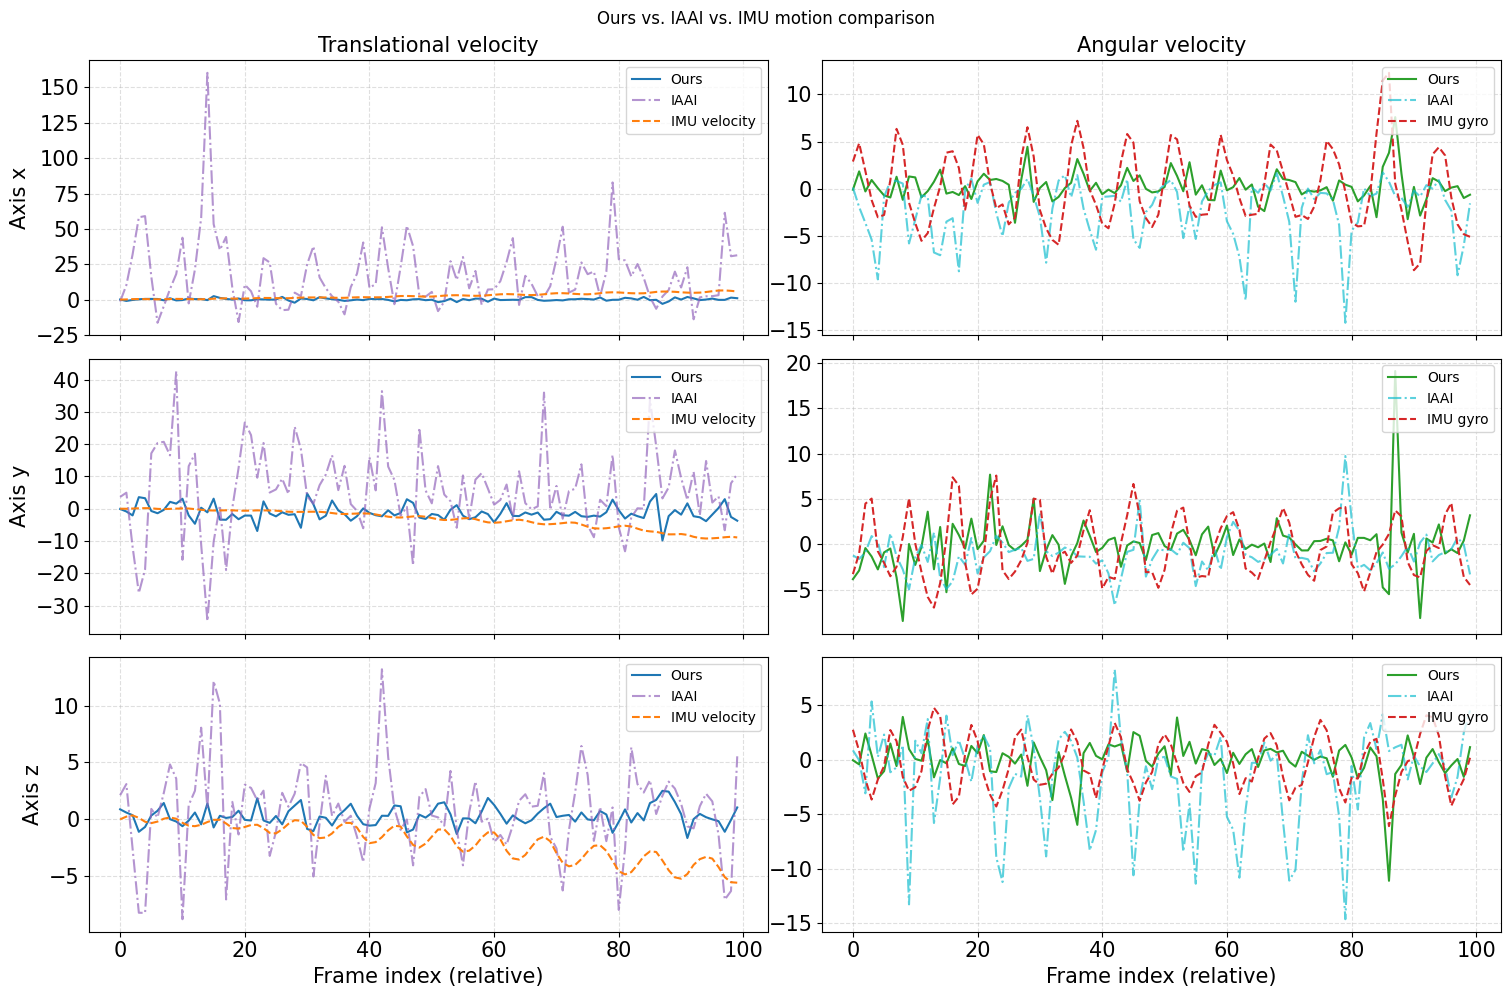

RMSE Angular Velocities Ours (rad/s):  [3.6575652  4.15472608 2.85762347]
RMSE Angular Velocities IAAI (rad/s):  [4.9424339  3.55182932 4.16801408]
RMSE Translational Velocities Ours (units/s):  [3.30212323 3.9877435  2.82992   ]
RMSE Translational Velocities IAAI (units/s):  [28.41763751 15.76245596  4.82195629]


In [13]:
def load_imu_csv(path: Path) -> dict[str, np.ndarray]:
    data = np.genfromtxt(path, delimiter=",", skip_header=1)
    if data.ndim == 1:
        data = data[None, :]
    if data.shape[1] != 7:
        raise ValueError("CSV must have 7 columns: timestamp_ns and 6 IMU channels.")
    timestamps = data[:, 0] * 1e-9
    gyro = data[:, 1:4]
    lin_acc = data[:, 4:7]
    return {"time": timestamps, "gyro": gyro, "lin_acc": lin_acc}


def integrate_acceleration(time_s: np.ndarray, accel: np.ndarray) -> np.ndarray:
    if len(time_s) < 2:
        return np.zeros_like(accel)
    dt = np.diff(time_s, prepend=time_s[0])
    vel = np.zeros_like(accel)
    for i in range(1, len(time_s)):
        vel[i] = vel[i - 1] + 0.5 * (accel[i] + accel[i - 1]) * dt[i]
    return vel


def nearest_indices(reference_time_s: np.ndarray, query_time_s: np.ndarray) -> np.ndarray:
    """Return indices of reference_time_s that are closest to each query_time_s."""
    if reference_time_s.ndim != 1 or query_time_s.ndim != 1:
        raise ValueError("reference_time_s and query_time_s must be 1-D arrays")
    if reference_time_s.size == 0:
        raise ValueError("reference_time_s must not be empty")
    raw_right = np.searchsorted(reference_time_s, query_time_s)
    right = np.clip(raw_right, 0, reference_time_s.size - 1)
    left = np.clip(raw_right - 1, 0, reference_time_s.size - 1)
    choose_left = (raw_right > 0) & (
        (raw_right >= reference_time_s.size)
        | (np.abs(reference_time_s[left] - query_time_s) <= np.abs(reference_time_s[right] - query_time_s))
    )
    indices = right.copy()
    indices[choose_left] = left[choose_left]
    return indices


def plot_time_series(time_axis: np.ndarray, gyro: np.ndarray, lin_acc: np.ndarray, velocity: np.ndarray) -> None:
    rel_time = time_axis - time_axis[0]
    fig, axes = plt.subplots(3, 1, sharex=True, figsize=(11, 8))

    axes[0].plot(rel_time, gyro[:, 0], label="gyro_x")
    axes[0].plot(rel_time, gyro[:, 1], label="gyro_y")
    axes[0].plot(rel_time, gyro[:, 2], label="gyro_z")
    axes[0].set_ylabel("Gyro [rad/s]")
    axes[0].legend(loc="upper right")
    axes[0].grid(True, linestyle="--", alpha=0.4)

    axes[1].plot(rel_time, lin_acc[:, 0], label="acc_x")
    axes[1].plot(rel_time, lin_acc[:, 1], label="acc_y")
    axes[1].plot(rel_time, lin_acc[:, 2], label="acc_z")
    axes[1].set_ylabel("Acc [m/s²]")
    axes[1].legend(loc="upper right")
    axes[1].grid(True, linestyle="--", alpha=0.4)

    axes[2].plot(rel_time, velocity[:, 0], label="vel_x")
    axes[2].plot(rel_time, velocity[:, 1], label="vel_y")
    axes[2].plot(rel_time, velocity[:, 2], label="vel_z")
    axes[2].set_ylabel("Velocity [m/s]")
    axes[2].set_xlabel("Relative time [s]")
    axes[2].legend(loc="upper right")
    axes[2].grid(True, linestyle="--", alpha=0.4)

    fig.suptitle("IMU time series")
    fig.tight_layout()
    plt.show()
# Aggregate velocities from both methods
angular_velocities_iaai = np.array([vel[0] for vel in iaai_rot_vel_list])
translational_velocities_iaai = np.array([vel[1] for vel in iaai_rot_vel_list])
angular_velocities = np.array([vel[0] for vel in velocities_list])
translational_velocities = np.array([vel[1] for vel in velocities_list])
if angular_velocities.size == 0 or translational_velocities.size == 0:
    raise RuntimeError("velocities_list is empty. Ensure the inference cell ran successfully.")
if angular_velocities_iaai.size == 0 or translational_velocities_iaai.size == 0:
    raise RuntimeError("iaai_rot_vel_list is empty. Ensure the inference cell ran successfully.")

# apply transform to angular velocities (regular method)
for idx in range(angular_velocities.shape[0]):
    angular_velocities[idx] = np.array([-angular_velocities[idx][1], angular_velocities[idx][0], angular_velocities[idx][2]])
    angular_velocities_iaai[idx] = np.array([-angular_velocities_iaai[idx][1], angular_velocities_iaai[idx][0], angular_velocities_iaai[idx][2]])

# Load IMU data and derive velocity via trapezoidal integration
imu_csv_path = input_folder / "imu.csv"
imu_data = load_imu_csv(imu_csv_path)
gyro = imu_data["gyro"]
lin_acc = imu_data["lin_acc"]
time_s = imu_data["time"]

# Align IMU samples with frame timestamps
frame_ts_ns = frame_timestamps_ns
if frame_ts_ns is None or len(frame_ts_ns) == 0:
    raise RuntimeError("frame_timestamps_ns is not available. Run the motion inference cell before sampling IMU data.")
frame_ts_ns = np.asarray(frame_ts_ns, dtype=np.int64)
frame_time_s = frame_ts_ns * 1e-9
closest_indices = nearest_indices(time_s, frame_time_s)
gyro_samples = gyro[closest_indices]
lin_acc_samples = lin_acc[closest_indices]
lin_acc_samples = lin_acc[closest_indices]

velocity = integrate_acceleration(time_s[closest_indices], lin_acc_samples)
velocity_samples = velocity



sample_count = len(frame_time_s)
relative_axis = np.linspace(0.0, (sample_count - 1) * 1.0, sample_count)

# Trim sequences to the same length in case of minor mismatches
min_len = min(sample_count, angular_velocities.shape[0], translational_velocities.shape[0], 
              angular_velocities_iaai.shape[0], translational_velocities_iaai.shape[0])
relative_axis = relative_axis[:min_len]
gyro_samples = gyro_samples[:min_len]
velocity_samples = velocity_samples[:min_len]
lin_acc_samples = lin_acc_samples[:min_len]
angular_velocities = angular_velocities[:min_len]
translational_velocities = translational_velocities[:min_len]
angular_velocities_iaai = angular_velocities_iaai[:min_len]
translational_velocities_iaai = translational_velocities_iaai[:min_len]

# Plot 6 graphs comparing computed motion with ground-truth IMU readings
fig, axes = plt.subplots(3, 2, figsize=(15, 10), sharex=True)
components = ["x", "y", "z"]

for idx, comp in enumerate(components):
    ax_trans = axes[idx, 0]
    ax_rot = axes[idx, 1]
    
    # Plot both methods for translation
    ax_trans.plot(relative_axis, translational_velocities[:, idx], label="Ours", color="tab:blue")
    ax_trans.plot(relative_axis, translational_velocities_iaai[:, idx], label="IAAI", color="tab:purple", linestyle="-.", alpha=0.7)
    ax_trans.plot(relative_axis, velocity_samples[:, idx], label="IMU velocity", color="tab:orange", linestyle="--")
    ax_trans.set_ylabel(f"Axis {comp}")
    ax_trans.grid(True, linestyle="--", alpha=0.4)
    if idx == 0:
        ax_trans.set_title("Translational velocity")
    if idx == len(components) - 1:
        ax_trans.set_xlabel("Frame index (relative)")
    ax_trans.legend(loc="upper right")

    # Plot both methods for rotation
    ax_rot.plot(relative_axis, angular_velocities[:, idx], label="Ours", color="tab:green")
    ax_rot.plot(relative_axis, angular_velocities_iaai[:, idx], label="IAAI", color="tab:cyan", linestyle="-.", alpha=0.7)
    ax_rot.plot(relative_axis, gyro_samples[:, idx], label="IMU gyro", color="tab:red", linestyle="--")
    ax_rot.grid(True, linestyle="--", alpha=0.4)
    if idx == 0:
        ax_rot.set_title("Angular velocity")
    if idx == len(components) - 1:
        ax_rot.set_xlabel("Frame index (relative)")
    ax_rot.legend(loc="upper right")

fig.suptitle("Ours vs. IAAI vs. IMU motion comparison")
fig.tight_layout()

# Enhance font sizes for publication-quality figures
for ax_row in axes:
    for ax in ax_row:
        ax.title.set_fontsize(15)
        ax.xaxis.label.set_fontsize(15)
        ax.yaxis.label.set_fontsize(15)
        for label in (ax.get_xticklabels() + ax.get_yticklabels()):
            label.set_fontsize(15)
plt.show()
# Compute Root Mean Square Error (RMSE) for quantitative comparison
if angular_velocities.shape != gyro_samples.shape:
    raise RuntimeError("Shape mismatch between angular_velocities and gyro_samples for RMSE calculation.")
rmse_angular = np.sqrt(np.mean((angular_velocities - gyro_samples) ** 2, axis=0))
rmse_angular_iaai = np.sqrt(np.mean((angular_velocities_iaai - gyro_samples) ** 2, axis=0))
print("RMSE Angular Velocities Ours (rad/s): ", rmse_angular)
print("RMSE Angular Velocities IAAI (rad/s): ", rmse_angular_iaai)

if translational_velocities.shape != velocity_samples.shape:
    raise RuntimeError("Shape mismatch between translational_velocities and velocity_samples for RMSE calculation.")
rmse_translational = np.sqrt(np.mean((translational_velocities - velocity_samples) ** 2, axis=0))
rmse_translational_iaai = np.sqrt(np.mean((translational_velocities_iaai - velocity_samples) ** 2, axis=0))
print("RMSE Translational Velocities Ours (units/s): ", rmse_translational)
print("RMSE Translational Velocities IAAI (units/s): ", rmse_translational_iaai)

In [12]:
# # Outdoor scene
# RMSE Angular Velocities Ours (rad/s):  [3.72476122 3.94676552 2.74704207]
# RMSE Angular Velocities IAAI (rad/s):  [3.94500418 3.14638223 3.70051706]
# RMSE Translational Velocities Ours (units/s):  [3.39001946 3.67844158 2.89953959]
# RMSE Translational Velocities IAAI (units/s):  [ 23.02924404 127.72871429   4.59566982]

In [ ]:
# Indoor scene
# RMSE Angular Velocities Ours (rad/s):  [4.53049384 5.38563959 3.7419178 ]
# RMSE Angular Velocities IAAI (rad/s):  [4.21807498 3.71433412 4.75623537]
# RMSE Translational Velocities Ours (units/s):  [5.2661584  7.80799744 1.69496075]
# RMSE Translational Velocities IAAI (units/s):  [ 56.63748045 151.11735231   4.2152179 ]

In [ ]:
# new college scene
# RMSE Angular Velocities Ours (rad/s):  [4.14572118 2.70472732 3.38781613]
# RMSE Angular Velocities IAAI (rad/s):  [4.02612624 3.51698964 4.22960282]
# RMSE Translational Velocities Ours (units/s):  [ 3.51867763  9.3464437  18.37344376]
# RMSE Translational Velocities IAAI (units/s):  [ 42.41581328 188.1863771   21.36807584]